<div dir="rtl" align="justify">

# تحلیل سری زمانی مصرف برق
<div dir="rtl" align="justify">

## سناریوی پروژه
<div dir="rtl" align="justify">
این گزارش با هدف بررسی الگوی مصرف برق مشترکان خانگی و تحلیل رفتار مصرف در طول زمان تهیه شده است. تمرکز اصلی این تحلیل، شناسایی روندهای بلندمدت، الگوهای فصلی و نوسانات مصرف برق است تا با درک بهتر رفتار مصرف، امکان پیش‌بینی تقاضای آینده و پشتیبانی از تصمیم‌گیری‌های مرتبط با برنامه‌ریزی، مدیریت منابع و بهینه‌سازی توزیع انرژی فراهم شود.
<div dir="rtl" align="justify">
برای دستیابی به این هدف، داده‌های تاریخی مصرف برق در چند مرحله مورد بررسی قرار گرفتند. ابتدا کیفیت و ساختار داده‌ها ارزیابی و آماده‌سازی شد، سپس تحلیل‌های آماری و سری زمانی برای شناسایی روند، فصل‌مندی و ایستایی داده‌ها انجام گرفت. در ادامه، با استفاده از مدل‌های پیش‌بینی  و**ARIMA**,**Prophet**و**SARIMA**، میزان مصرف برق پیش‌بینی و عملکرد این مدل‌ها با استفاده از شاخص‌های ارزیابی و مقایسه نتایج بررسی شد تا مناسب‌ترین مدل برای پیش‌بینی مصرف برق مشخص شود.
</div>

<div dir="rtl" align="justify">

# مبنای علمی و چارچوب اجرای پروژه
<div dir="rtl" align="justify">
ترتیب مراحل این پروژه بر اساس منابع معتبر حوزه تحلیل و پیش‌بینی سری زمانی طراحی شده است. در تدوین فرآیند اجرای پروژه، از مقالات و کتاب‌های مرجع استفاده شده تا مراحل آماده‌سازی داده، تحلیل سری زمانی، بررسی ایستایی، تجزیه سری زمانی، مدل‌سازی و ارزیابی مدل‌ها مطابق با رویه‌های استاندارد انجام شود.
<div dir="rtl" align="justify">
به‌ویژه، مقاله **Analysis and Modeling to Forecast in Time Series: A Systematic Review** به‌عنوان مرجع اصلی برای تعیین ترتیب مراحل پروژه مورد استفاده قرار گرفت. این مقاله فرآیند استاندارد پروژه‌های پیش‌بینی سری زمانی را شامل آماده‌سازی داده، تحلیل اولیه، بررسی ایستایی، تجزیه سری زمانی، مدل‌سازی و ارزیابی پیش‌بینی معرفی می‌کند. 
<div dir="rtl" align="justify">
---

## منابع علمی

**Dama, F., & Sinoquet, C. (2021).**  
*Analysis and Modeling to Forecast in Time Series: A Systematic Review.*

لینک مقاله:  
https://www.researchgate.net/publication/350577796_Analysis_and_modeling_to_forecast_in_time_series_a_systematic_review

---

**Hyndman, R. J., & Athanasopoulos, G. (2021).**  
*Forecasting: Principles and Practice (3rd Edition).*

لینک کتاب:  
https://otexts.com/fpp3/

</div>

<div dir="rtl" align="justify">

# خلاصه منابع علمی مورد استفاده
<div dir="rtl" align="justify">
---

## 1. Analysis and Modeling to Forecast in Time Series: A Systematic Review (2021)
<div dir="rtl" align="justify">
این مقاله یک مرور جامع بر روش‌های تحلیل و پیش‌بینی سری زمانی ارائه می‌دهد و مراحل استاندارد اجرای پروژه‌های سری زمانی را از آماده‌سازی داده تا ارزیابی مدل تشریح می‌کند. در این مقاله بر اهمیت بررسی کیفیت داده، تحلیل ایستایی، تجزیه سری زمانی، انتخاب مدل مناسب و ارزیابی عملکرد پیش‌بینی تأکید شده است. .


## 2. Forecasting: Principles and Practice (3rd Edition)
<div dir="rtl" align="justify">
این کتاب یکی از منابع حوزه پیش‌بینی سری زمانی است و مفاهیم اصلی مانند روند، فصل‌مندی، آزمون‌های ایستایی، مدل‌های ARIMA، Prophet و معیارهای ارزیابی مدل را به‌صورت کاربردی توضیح می‌دهد.
</div>

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from prophet import Prophet
from sklearn.metrics import (mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,r2_score)

In [2]:
file_path =r"C:\Users\Abbas\Desktop\انجام پروژه\هفته چهارم\تسک دوم\household_power_consumption.txt"
df = pd.read_csv(file_path,sep=";",na_values="?",low_memory=False)

In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [5]:
df.describe(include="all")

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075259,2075259,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
unique,1442,1440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,6/12/2008,17:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1440,1442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,NaN,NaN,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,NaN,NaN,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,NaN,NaN,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,NaN,NaN,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01


In [6]:
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"],dayfirst=True)
df = df.drop(columns=["Date", "Time"])
df = df.set_index("Datetime")

In [7]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [8]:
missing = df.isnull().sum()
missing_percent = (missing /len(df)) * 100
pd.DataFrame({"Missing": missing,"Percent": missing_percent})

,Missing,Percent
Global_active_power,25979,1.251844
Global_reactive_power,25979,1.251844
Voltage,25979,1.251844
Global_intensity,25979,1.251844
Sub_metering_1,25979,1.251844
Sub_metering_2,25979,1.251844
Sub_metering_3,25979,1.251844


In [9]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(168560)

In [10]:
time_diff = (df.index.to_series().diff())
duplicate_time = (time_diff != pd.Timedelta(minutes=1)).sum()
duplicate_time

np.int64(1)

In [11]:
cols = [
"Global_active_power",
"Global_reactive_power",
"Voltage",
"Global_intensity",
"Sub_metering_1",
"Sub_metering_2",
"Sub_metering_3"
]
for col in cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [12]:
monthly_power = (df["Global_active_power"].resample("ME").sum())

In [13]:
monthly_power.head()

Datetime
2006-12-31    41813.282
2007-01-31    69011.862
2007-02-28    56488.886
2007-03-31    58862.192
2007-04-30    35181.466
Freq: ME, Name: Global_active_power, dtype: float64

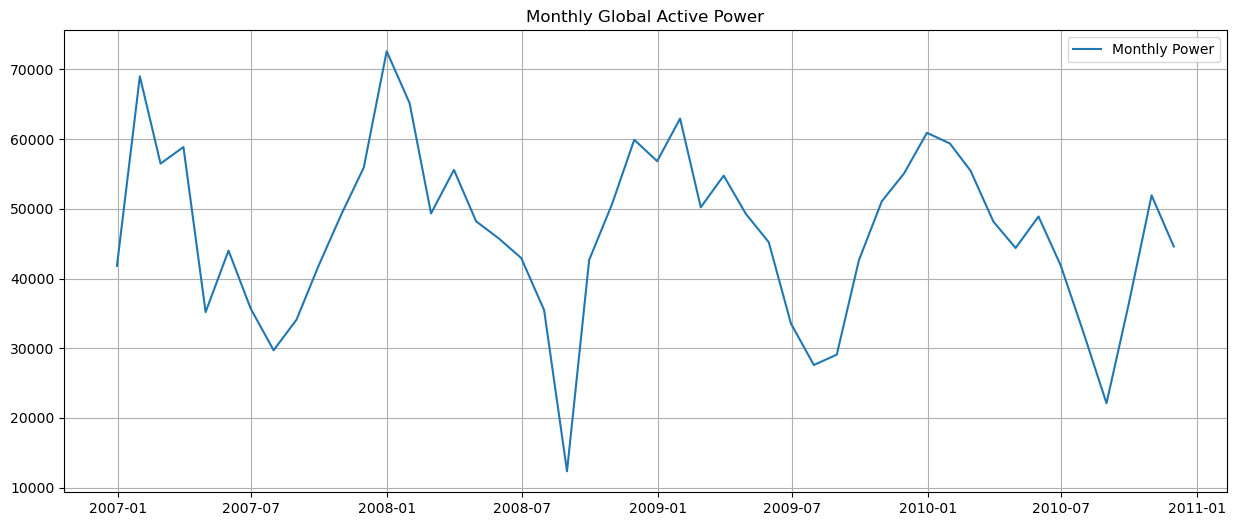

In [14]:
plt.figure(figsize=(15,6))
plt.plot(monthly_power,label="Monthly Power")
plt.title("Monthly Global Active Power")
plt.grid(True)
plt.legend()
plt.show()

<div dir="rtl" align="justify">

# تحلیل بخش اول: شناخت داده و پیش‌پردازش (Data Understanding & Data Preprocessing)

---

## هدف این مرحله
<div dir="rtl" align="justify">
در ابتدای پروژه، کیفیت و ساختار داده‌ها مورد بررسی قرار گرفت تا از مناسب بودن اطلاعات برای تحلیل سری زمانی و مدل‌سازی اطمینان حاصل شود. در این مرحله وضعیت داده‌ها از نظر حجم، نوع متغیرها، داده‌های مفقود، داده‌های تکراری، پیوستگی زمانی و آماده‌سازی برای تحلیل ارزیابی شد.

---

## تحلیل نتایج
<div dir="rtl" align="justify">
بررسی اولیه داده‌ها نشان داد مجموعه داده شامل **2,075,259 رکورد** و **9 ستون** است که حجم نسبتاً بالایی از اطلاعات مصرف برق را پوشش می‌دهد. همچنین مشخص شد هفت ستون دارای نوع داده عددی (`float64`) و دو ستون مربوط به تاریخ و زمان از نوع متنی (`object`) هستند. این موضوع نشان می‌دهد داده‌ها از نظر ساختار اولیه برای تحلیل مناسب بوده‌اند، اما لازم است ستون‌های تاریخ و زمان به یک متغیر زمانی واحد تبدیل شوند تا امکان انجام تحلیل سری زمانی فراهم شود.
<div dir="rtl" align="justify">
در ادامه، کیفیت داده‌ها از نظر مقادیر مفقود بررسی شد. نتایج نشان داد هر هفت متغیر اصلی دارای **25,979 مقدار مفقود** هستند که معادل **1.25 درصد** از کل داده‌ها است. با توجه به پایین بودن این درصد نسبت به حجم کل داده‌ها، می‌توان نتیجه گرفت که کیفیت کلی داده مناسب است و مقادیر مفقود تأثیر قابل‌توجهی بر روند کلی تحلیل نخواهند داشت، مشروط بر اینکه در مراحل بعدی به‌درستی مدیریت شوند.
<div dir="rtl" align="justify">
بررسی داده‌های تکراری نیز نشان داد **168,560 رکورد تکراری** در مجموعه داده وجود دارد. وجود این تعداد رکورد تکراری می‌تواند باعث افزایش حجم پردازش و ایجاد سوگیری در تحلیل شود؛ بنابراین شناسایی آن‌ها از اهمیت بالایی برخوردار است و در پروژه باید مشخص شود که این تکرارها ناشی از ثبت مجدد اطلاعات هستند یا بخشی از ماهیت واقعی داده‌ها محسوب می‌شوند.
<div dir="rtl" align="justify">
در بخش بررسی توالی زمانی، تنها **یک ناهماهنگی در فاصله زمانی** مشاهده شد. این نتیجه نشان می‌دهد ترتیب زمانی داده‌ها تقریباً به‌صورت کامل حفظ شده و پیوستگی سری زمانی در کل مجموعه داده برقرار است؛ موضوعی که برای مدل‌های پیش‌بینی اهمیت زیادی دارد.
<div dir="rtl" align="justify">
پس از آماده‌سازی داده‌ها، اطلاعات مصرف برق از مقیاس دقیقه‌ای به مقیاس **ماهانه** تبدیل شد. این تبدیل باعث کاهش نوسانات کوتاه‌مدت و تمرکز تحلیل بر روندهای بلندمدت و الگوهای فصلی شد 
<div dir="rtl" align="justify">
نمودار سری زمانی ماهانه نیز نشان می‌دهد میزان مصرف برق در طول دوره مورد بررسی یکنواخت نبوده و تغییرات محسوسی را تجربه کرده است. در ابتدای سال 2008 بیشترین میزان مصرف مشاهده می‌شود، در حالی که در نیمه دوم همان سال کاهش شدیدی در مصرف ثبت شده است. همچنین در سال‌های بعد نیز الگوی افزایش و کاهش مصرف به‌صورت تکرارشونده دیده می‌شود که می‌تواند نشان‌دهنده وجود روند و رفتارهای فصلی در داده‌ها باشد. این موضوع بیان می‌کند که داده‌ها از ویژگی‌های لازم برای انجام تحلیل سری زمانی و استفاده از مدل‌های پیش‌بینی برخوردار هستند.

---

## جمع‌بندی
<div dir="rtl" align="justify">
نتایج این مرحله نشان می‌دهد مجموعه داده از کیفیت مناسبی برای ادامه تحلیل برخوردار است. درصد پایین داده‌های مفقود، وجود تنها یک ناهماهنگی زمانی و مشاهده الگوهای مشخص در نمودار مصرف ماهانه، بیانگر آن است که داده‌ها پس از انجام مراحل آماده‌سازی، قابلیت ورود به مرحله تحلیل سری زمانی و مدل‌سازی را دارند.

---
</div>

In [15]:
moving_average_12 = monthly_power.rolling(window=12).mean()

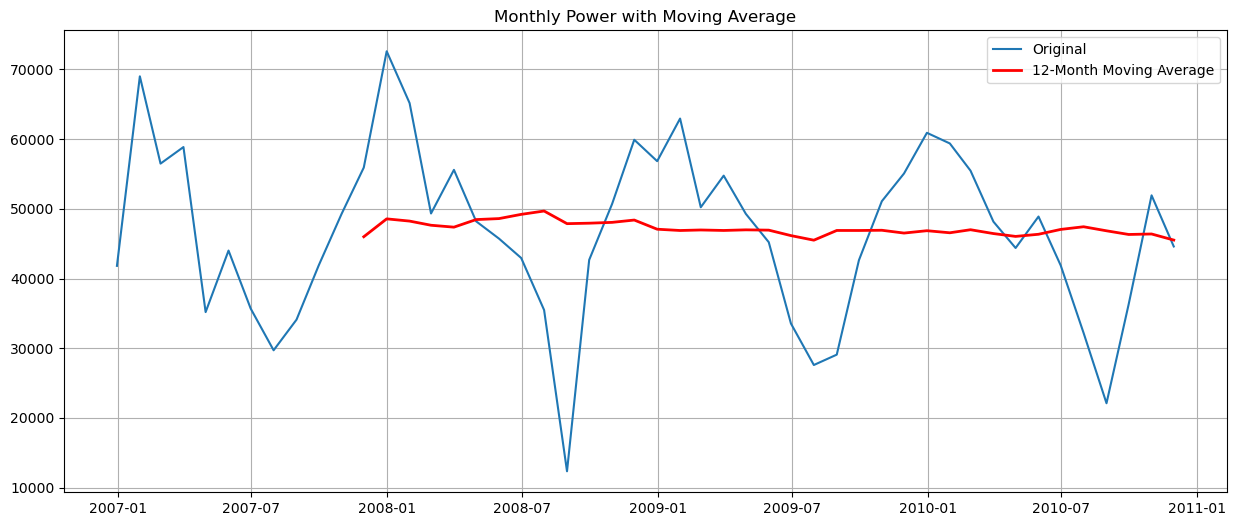

In [16]:
plt.figure(figsize=(15,6))
plt.plot(monthly_power,label="Original")
plt.plot(moving_average_12,color="red",linewidth=2,label="12-Month Moving Average")
plt.title("Monthly Power with Moving Average")
plt.grid(True)
plt.legend()
plt.show()

<div dir="rtl" align="justify">

# تحلیل بخش دوم: بررسی روند مصرف برق با استفاده از میانگین متحرک (Moving Average)

---

## هدف این مرحله
<div dir="rtl" align="justify">
در این مرحله از میانگین متحرک 12 ماهه (12-Month Moving Average) استفاده شد تا نوسانات کوتاه‌مدت داده‌ها کاهش یافته و روند اصلی تغییرات مصرف برق با وضوح بیشتری قابل مشاهده باشد.

---

## تحلیل نتایج
<div dir="rtl" align="justify">
مقایسه نمودار اصلی مصرف برق با میانگین متحرک نشان می‌دهد که داده‌های اولیه دارای نوسانات قابل‌توجهی هستند و در برخی ماه‌ها افزایش یا کاهش شدیدی در میزان مصرف مشاهده می‌شود. این نوسانات می‌توانند ناشی از تغییرات فصلی، شرایط محیطی یا تغییر الگوی مصرف باشند.
<div dir="rtl" align="justify">
 خط میانگین متحرک با حذف بخش زیادی از این نوسانات، روند کلی مصرف برق را نمایش می‌دهد. همان‌طور که در نمودار مشاهده می‌شود، مقدار میانگین متحرک طی کل دوره تقریباً در محدوده **45 تا 49 هزار واحد** قرار دارد و تغییرات آن بسیار ملایم‌تر از داده‌های اصلی است. این موضوع نشان می‌دهد که اگرچه مصرف برق در برخی ماه‌ها با افزایش یا کاهش شدید همراه بوده، اما روند بلندمدت مصرف در کل دوره نسبتاً پایدار باقی مانده است.
<div dir="rtl" align="justify">
 اختلاف قابل مشاهده بین خط آبی (داده واقعی) و خط قرمز (میانگین متحرک) در برخی بازه‌ها، به‌ویژه در نیمه دوم سال 2008 و نیمه دوم سال 2010، بیانگر وجود نوسانات غیرعادی یا تغییرات کوتاه‌مدت در مصرف برق است. نزدیک شدن این دو خط در برخی ماه‌ها نشان می‌دهد که مقدار واقعی مصرف با روند بلندمدت همخوانی بیشتری داشته است.
<div dir="rtl" align="justify">
 میانگین متحرک نشان می‌دهد که با وجود نوسانات مقطعی، روند بلندمدت مصرف برق در بازه زمانی مورد بررسی تغییر چشمگیری نداشته و عمده تغییرات مشاهده‌شده مربوط به نوسانات کوتاه‌مدت است.

---

## جمع‌بندی
<div dir="rtl" align="justify">
نتایج این مرحله نشان می‌دهد که سری زمانی دارای نوسانات کوتاه‌مدت قابل توجهی است، اما روند بلندمدت آن نسبتاً پایدار باقی مانده است. استفاده از میانگین متحرک باعث شد روند اصلی داده‌ها با وضوح بیشتری مشخص شود و دید مناسبی برای ادامه تحلیل‌های آماری، بررسی ایستایی سری زمانی و انتخاب مدل پیش‌بینی فراهم گردد.

---
</div>

In [17]:
result = adfuller(monthly_power.dropna())
print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Critical Values :")
for key, value in result[4].items():
    print(f"{key} : {value}")

ADF Statistic : -6.5972980985272045
p-value : 6.874210217931087e-09
Critical Values :
1% : -3.6055648906249997
5% : -2.937069375
10% : -2.606985625


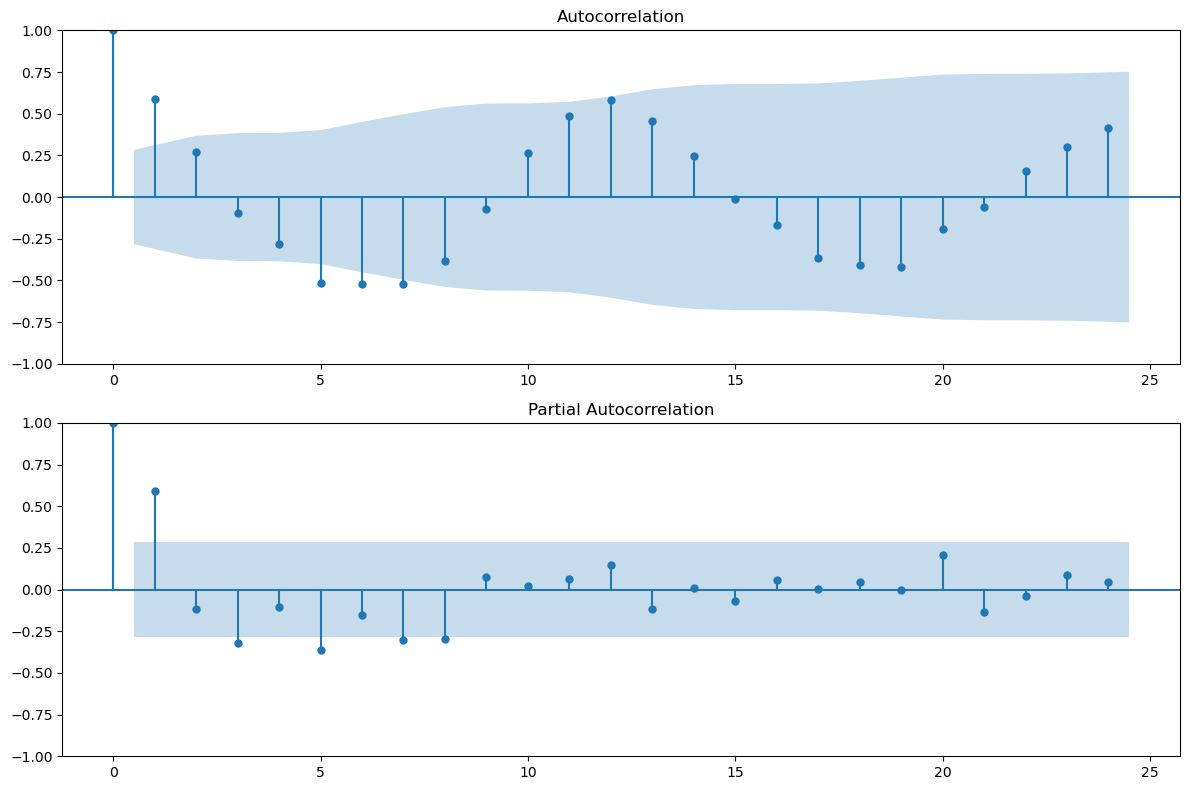

In [18]:
fig, axes = plt.subplots(2,1,figsize=(12,8))
plot_acf(monthly_power.dropna(),lags=24,ax=axes[0])
plot_pacf(monthly_power.dropna(),lags=24,ax=axes[1])
plt.tight_layout()
plt.show()

<div dir="rtl" align="justify">

# تحلیل: بررسی ایستایی و وابستگی زمانی سری (Stationarity Analysis)

---

## هدف این مرحله
<div dir="rtl" align="justify">
در این مرحله، وضعیت ایستایی سری زمانی و میزان وابستگی داده‌ها به مقادیر گذشته بررسی شد تا مشخص شود آیا داده‌ها برای مدل‌سازی سری زمانی مناسب هستند و الگوی مشخصی در رفتار آن‌ها وجود دارد یا خیر.

---

## تحلیل نتایج
<div dir="rtl" align="justify">
نتایج آزمون  نشان داد مقدار آماره آزمون برابر با **6.597-** و مقدار **p-value برابر با 0.0000000069** است که به‌مراتب کمتر از سطح خطای 0.05 می‌باشد. همچنین مقدار آماره آزمون از تمامی مقادیر بحرانی در سطوح **1%، 5% و 10%** کوچک‌تر است. این نتایج نشان می‌دهد فرض وجود ریشه واحد رد شده و سری زمانی از نظر آماری **ایستا (Stationary)** است.
<div dir="rtl" align="justify">
ایستا بودن سری زمانی بیان می‌کند که ویژگی‌های آماری داده‌ها در طول زمان تغییر قابل‌توجهی نداشته و میانگین و واریانس سری در طول دوره مورد بررسی نسبتاً پایدار باقی مانده‌اند. این موضوع یکی از مهم‌ترین شرایط برای استفاده از بسیاری از مدل‌های پیش‌بینی از جمله ARIMA محسوب می‌شود.
<div dir="rtl" align="justify">
بررسی نمودار ACF نیز نشان می‌دهد که در وقفه‌های ابتدایی، همبستگی بین مشاهدات نسبتاً بالا است و سپس این همبستگی به‌تدریج کاهش پیدا می‌کند. علاوه بر این، مشاهده افزایش مجدد ضرایب همبستگی در حوالی وقفه 12 و 24 ماه، وجود یک الگوی تکرارشونده سالانه را نشان می‌دهد که بیانگر تأثیر فصل‌مندی در رفتار مصرف برق است.
<div dir="rtl" align="justify">
در نمودار PACF نیز بیشترین وابستگی در وقفه اول مشاهده می‌شود و پس از آن مقدار ضرایب به‌طور محسوسی کاهش پیدا می‌کند. این رفتار نشان می‌دهد که بیشترین تأثیر بر مصرف هر ماه، از مقادیر ماه قبل ناشی می‌شود و اثر وقفه‌های دورتر به‌مراتب کمتر است.
<div dir="rtl" align="justify">
در مجموع، نتایج آزمون ADF و نمودارهای ACF و PACF نشان می‌دهد که داده‌ها علاوه بر ایستا بودن، دارای وابستگی زمانی و الگوهای فصلی مشخص هستند. این ویژگی‌ها تأیید می‌کند که استفاده از مدل‌های سری زمانی مانند Prophet و ARIMA برای پیش‌بینی این مجموعه داده انتخاب مناسبی خواهد بود.

---

## جمع‌بندی
<div dir="rtl" align="justify">
بررسی‌های آماری نشان داد سری زمانی از نظر آماری ایستا بوده و الگوهای وابستگی زمانی و فصل‌مندی در آن مشاهده می‌شود. بنابراین داده‌ها شرایط لازم برای ورود به مرحله تجزیه سری زمانی و سپس مدل‌سازی پیش‌بینی را دارا هستند.
</div>

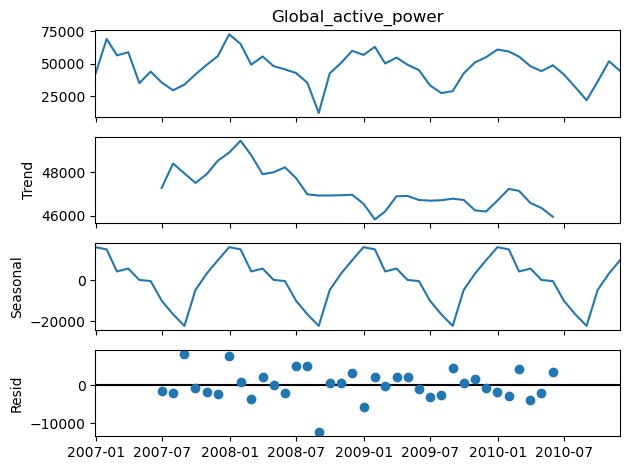

In [19]:
decomposition_add = seasonal_decompose(monthly_power,model="additive",period=12)
decomposition_add.plot()
plt.tight_layout()
plt.show()

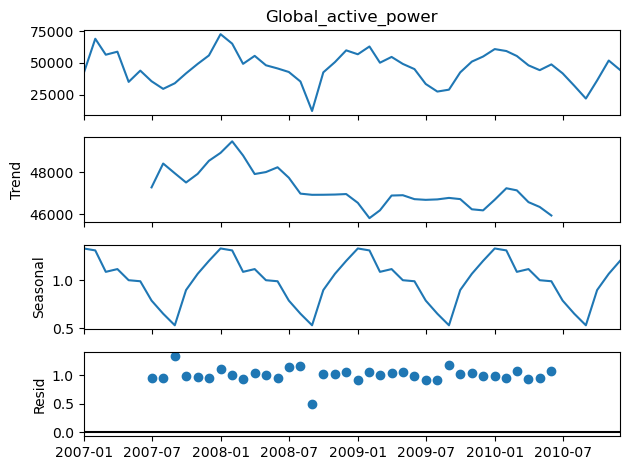

In [20]:
decomposition_mul = seasonal_decompose(monthly_power,model="multiplicative",period=12)
decomposition_mul.plot()
plt.tight_layout()
plt.show()

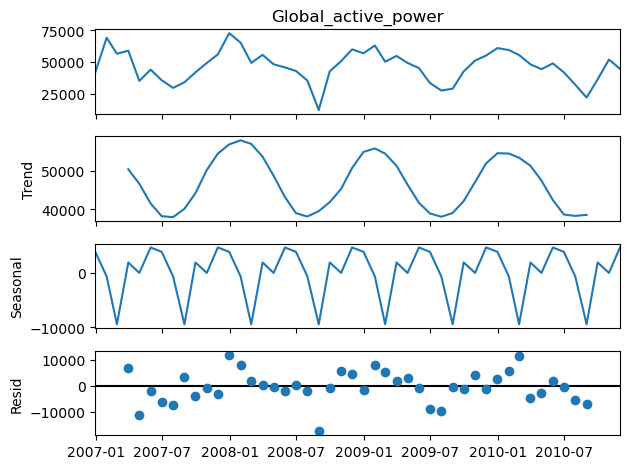

In [54]:
wrong_decomposition = seasonal_decompose(monthly_power,model="additive",period=6)
wrong_decomposition.plot()
plt.tight_layout()
plt.show()

<div dir="rtl" align="justify">
استفاده از مدل Additive (جمعی) برای این داده‌ها مناسب‌تر است.
<div dir="rtl" align="justify">
دلایل و تحلیل مقایسه‌ای 
<div dir="rtl" align="justify">
بررسی دامنه تغییرات فصلی (Seasonal Amplitude): در مدل‌های سری زمانی، اگر با افزایش یا کاهش سطح روند (Trend)، دامنه و شدت نوسانات فصلی (پیک‌ها و دره‌ها) تغییر چشمگیری نکند و تقریباً ثابت بماند، مدل Additive انتخاب اصلی است. اما اگر با بالا رفتن روند، نوسانات فصلی نیز به صورت موازی بزرگ‌تر و شدیدتر شوند، مدل Multiplicative مناسب خواهد بود.
<div dir="rtl" align="justify">
انطباق با رفتار مصرف برق خانگی (Global Active Power): با نگاه به داده‌های ریسمپل شده ماهانه ، مشاهده می‌کنیم که در طول سال‌های ۲۰۰۶ تا ۲۰۱۰، با وجود تغییرات ملایم در روند کلی، ارتفاع پیک‌های زمستانه و عمق دره‌های تابستانه سال به سال تغییر ساختاری و جهشی نداشته‌اند (دامنه نوسان حول روند ثابت است). بنابراین، فرض خطی و مستقل بودن نویز و فصل‌گرایی از روند (که پایه مدل Additive است) کاملاً صادق است.
<div dir="rtl" align="justify">
مؤلفه باقی‌مانده (Residuals): اگر برای این داده‌ها از مدل Multiplicative استفاده شود، به دلیل ثابت بودن دامنه واقعی، مدل تمایل پیدا می‌کند در نقاط کم‌مصرف نویزها را بیش از حد کوچک و در نقاط پرمصرف نویزها را بیش از حد بزرگ نشان دهد که باعث  واریانس  در نمودار Resid می‌شود. مدل Additive نویز پایدارتر و توزیع نرمال‌تری حول محور صفر ارائه می‌دهد.
</div>

<div dir="rtl" align="justify">

## اگر مقدار period به اشتباه برابر 6 در نظر گرفته شود، چه اثری بر مؤلفه Seasonal دارد؟
<div dir="rtl" align="justify">
داده‌های این پروژه به‌صورت **ماهانه (Monthly)** هستند؛ بنابراین اگر رفتار مصرف برق دارای فصل‌مندی سالانه باشد، دوره تناوب واقعی برابر با **12 ماه** خواهد بود. در این بخش، برای بررسی حساسیت مدل، مقدار **period** به‌صورت آزمایشی برابر **6** در نظر گرفته شد تا تأثیر انتخاب نادرست دوره فصلی بررسی شود.

### 1. ایجاد فصل‌مندی مصنوعی
<div dir="rtl" align="justify">
در خروجی مشاهده می‌شود که مؤلفه **Seasonal** هر شش ماه یک‌بار تکرار می‌شود. این در حالی است که رفتار واقعی مصرف برق در این مجموعه داده بر اساس چرخه‌های سالانه شکل گرفته است. بنابراین مدل به‌جای استخراج الگوی واقعی، یک الگوی شش‌ماهه مصنوعی ایجاد کرده که با ساختار داده مطابقت ندارد.

### 2. تحریف مؤلفه Trend
<div dir="rtl" align="justify">
در نمودار **Trend** به‌جای مشاهده یک روند نسبتاً هموار و بلندمدت، نوسانات دوره‌ای و موج‌های کوتاه‌مدت دیده می‌شود. علت این موضوع آن است که بخشی از تغییرات واقعی سالانه به اشتباه وارد مؤلفه روند شده و روند دیگر تنها تغییرات بلندمدت را نمایش نمی‌دهد.
<div dir="rtl" align="justify">
### 3. افزایش اطلاعات باقی‌مانده در Residual
<div dir="rtl" align="justify">
به دلیل انتخاب نادرست دوره تناوب، همه الگوهای فصلی از داده جدا نشده‌اند و بخشی از آن‌ها در مؤلفه **Residual** باقی مانده است. این موضوع نشان می‌دهد فرآیند تجزیه نتوانسته ساختار واقعی داده را به‌طور کامل استخراج کند.

### چرا period=12 انتخاب مناسب‌تری است؟
<div dir="rtl" align="justify">
از آنجا که داده‌ها به‌صورت ماهانه ثبت شده‌اند و الگوی مصرف برق در طول سال تکرار می‌شود، دوره تناوب طبیعی این سری زمانی **12 ماه** است. انتخاب **period=12** باعث می‌شود مؤلفه فصلی دقیقاً چرخه سالانه را نمایش دهد، روند بلندمدت بدون اعوجاج استخراج شود و باقی‌مانده‌ها رفتار تصادفی‌تری داشته باشند. در مقابل، انتخاب **period=6** باعث می‌شود مدل یک فصل‌مندی غیرواقعی ایجاد کند و بخشی از اطلاعات بین مؤلفه‌های Trend و Residual جابه‌جا شود؛ در نتیجه کیفیت تجزیه و دقت تحلیل کاهش پیدا می‌کند.

</div>

In [22]:
residual = decomposition_add.resid.dropna()

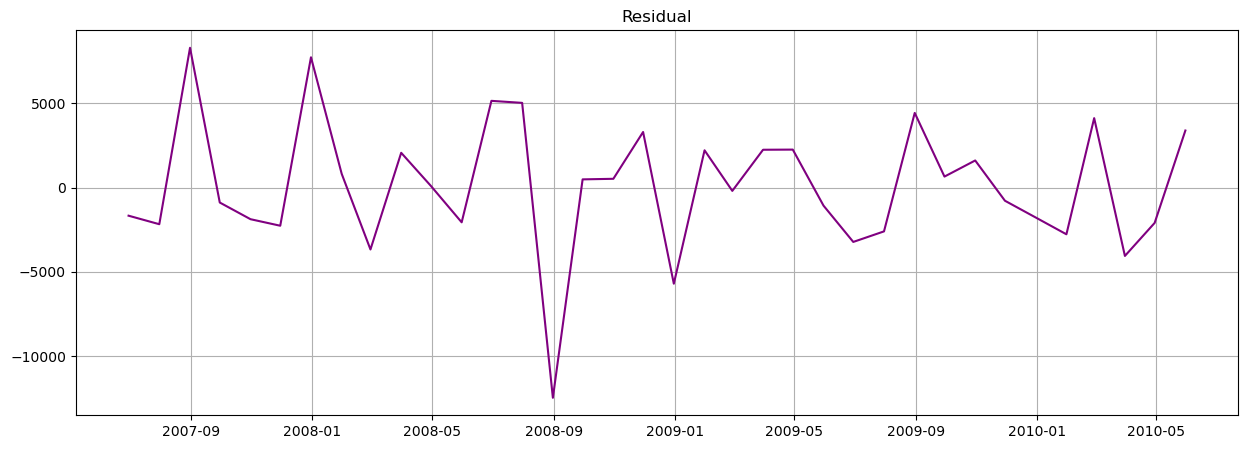

In [23]:
plt.figure(figsize=(15,5))
plt.plot(residual,color="purple")
plt.title("Residual")
plt.grid(True)
plt.show()

<Figure size 1000x400 with 0 Axes>

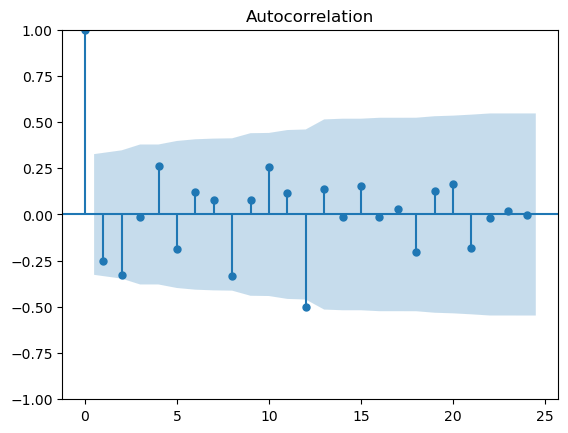

In [24]:
plt.figure(figsize=(10,4))
plot_acf(residual,lags=24)
plt.show()

In [25]:
ljung_box = acorr_ljungbox(residual,lags=[12],return_df=True)
ljung_box

,lb_stat,lb_pvalue
12,36.321789,0.000288


<div dir="rtl" align="justify">

# تحلیل: بررسی باقی‌مانده‌ها (Residual Analysis)
<div dir="rtl" align="justify">
---

## هدف این مرحله
<div dir="rtl" align="justify">
پس از تجزیه سری زمانی، لازم است بررسی شود آیا روند و فصل‌مندی به‌طور کامل از داده حذف شده‌اند یا خیر. برای این منظور، باقی‌مانده‌های مدل (Residuals) مورد ارزیابی قرار گرفتند. در یک تجزیه مناسب، انتظار می‌رود باقی‌مانده‌ها رفتاری مشابه نویز سفید داشته باشند؛ یعنی حول مقدار صفر نوسان کنند، الگوی مشخصی نداشته باشند و بین مقادیر آن‌ها وابستگی زمانی مشاهده نشود.
<div dir="rtl" align="justify">
---

## تحلیل نتایج
<div dir="rtl" align="justify">
نمودار باقی‌مانده‌ها نشان می‌دهد بیشتر مقادیر در اطراف خط صفر قرار گرفته‌اند و در طول دوره بررسی، روند مشخص یا افزایش و کاهش مداومی در خطاها دیده نمی‌شود. این موضوع بیان می‌کند که بخش عمده روند و فصل‌مندی از داده استخراج شده است. با این حال، در حوالی نیمه دوم سال 2008 یک افت قابل توجه در باقی‌مانده‌ها مشاهده می‌شود و در چند مقطع دیگر نیز نوساناتی بزرگ‌تر از سایر نقاط دیده می‌شود. این رفتار نشان می‌دهد برخی تغییرات غیرعادی هنوز توسط فرآیند تجزیه توضیح داده نشده‌اند.
<div dir="rtl" align="justify">
بررسی نمودار خودهمبستگی باقی‌مانده‌ها (Residual ACF) نیز نشان می‌دهد بیشتر ضرایب خودهمبستگی داخل محدوده اطمینان قرار دارند که بیانگر کاهش وابستگی زمانی در بخش زیادی از داده است. با این حال، در **وقفه 12** ضریب خودهمبستگی به‌طور واضح از محدوده اطمینان خارج شده است. این نتیجه نشان می‌دهد بخشی از الگوی فصلی سالانه همچنان در باقی‌مانده‌ها وجود دارد و مؤلفه فصلی به‌طور کامل از داده جدا نشده است. علاوه بر این، در چند وقفه دیگر نیز ضرایب به مرز محدوده اطمینان نزدیک هستند که می‌تواند نشان‌دهنده باقی ماندن بخشی از وابستگی‌های کوتاه‌مدت باشد.
<div dir="rtl" align="justify">
نتیجه آزمون **Ljung–Box** نیز این موضوع را تأیید می‌کند. همان‌طور که در خروجی مشاهده می‌شود، مقدار **p-value برابر با 0.000288** است که به‌مراتب کمتر از سطح معنی‌داری **0.05** است. بنابراین فرض صفر مبنی بر مستقل بودن باقی‌مانده‌ها رد می‌شود و از نظر آماری می‌توان نتیجه گرفت که هنوز مقداری خودهمبستگی در خطاهای مدل وجود دارد. این نتیجه با نمودار ACF نیز کاملاً هم‌خوانی دارد.
<div dir="rtl" align="justify">
---

## جمع‌بندی
<div dir="rtl" align="justify">
بررسی باقی‌مانده‌ها نشان می‌دهد فرآیند تجزیه سری زمانی توانسته بخش قابل توجهی از ساختار داده، شامل روند و بخش زیادی از فصل‌مندی، را استخراج کند؛ اما وجود خودهمبستگی معنی‌دار در وقفه 12 و نتیجه آزمون Ljung–Box نشان می‌دهد هنوز تمام اطلاعات زمانی موجود در داده حذف نشده است. به همین دلیل، استفاده از مدل‌های پیش‌بینی مانند **Prophet** و **ARIMA** در مرحله بعد اهمیت پیدا می‌کند؛ زیرا این مدل‌ها می‌توانند وابستگی‌های باقی‌مانده را بهتر یاد بگیرند و دقت پیش‌بینی را افزایش دهند.
<div dir="rtl" align="justify">
</div>

In [26]:
train_size = int(len(monthly_power) * 0.8)
train = monthly_power.iloc[:train_size]
test = monthly_power.iloc[train_size:]

In [27]:
train_prophet = train.reset_index()
train_prophet.columns = ["ds","y"]

In [28]:
model = Prophet(yearly_seasonality=True)
model.fit(train_prophet)

04:07:38 - cmdstanpy - INFO - Chain [1] start processing
04:07:39 - cmdstanpy - INFO - Chain [1] done processing


In [29]:
future = model.make_future_dataframe(periods=len(test),freq="ME")

In [30]:
forecast = model.predict(future)

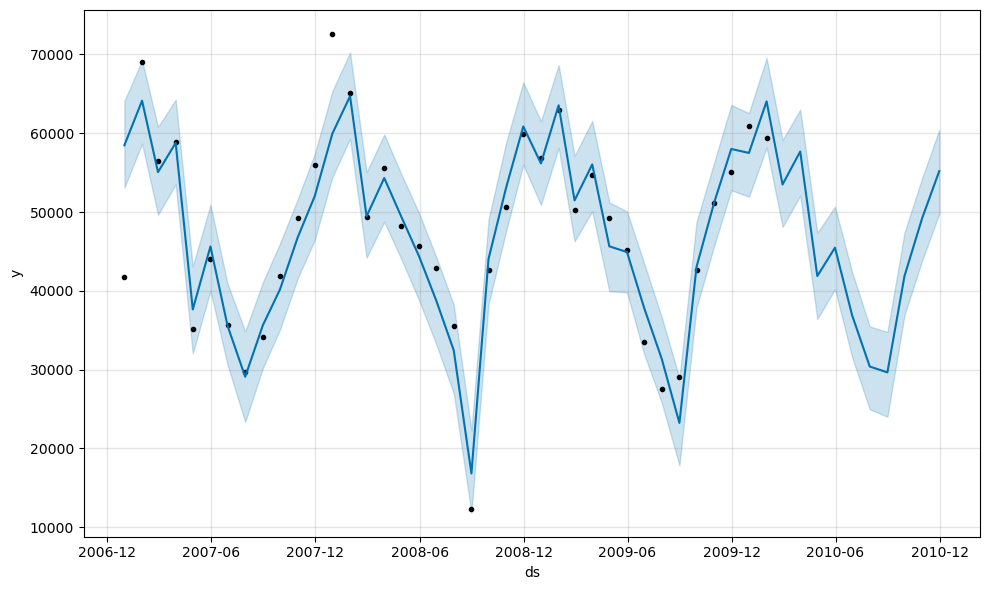

In [31]:
fig = model.plot(forecast)
plt.grid(True)
plt.show()

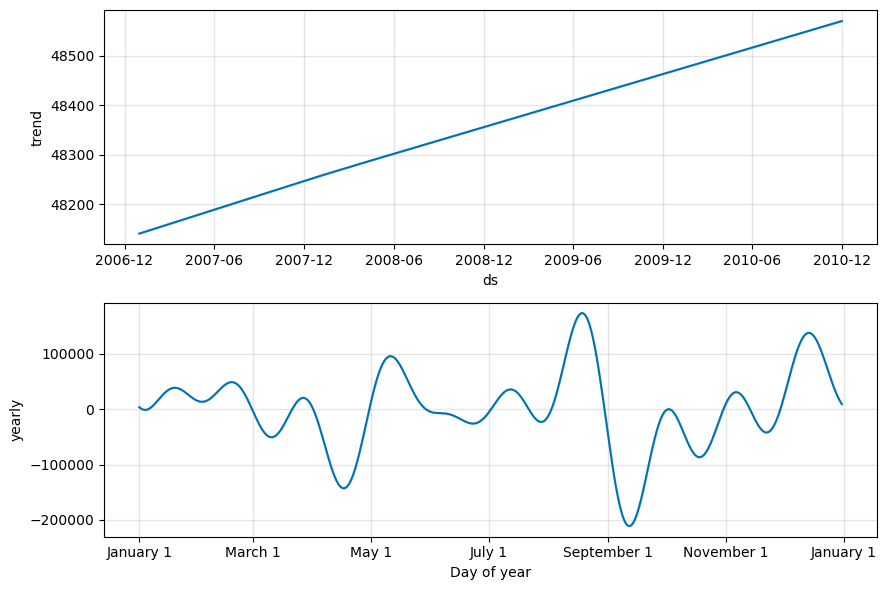

In [32]:
model.plot_components(forecast)
plt.show()

In [33]:
y_true = test.values
y_pred = forecast["yhat"].iloc[-len(test):].values

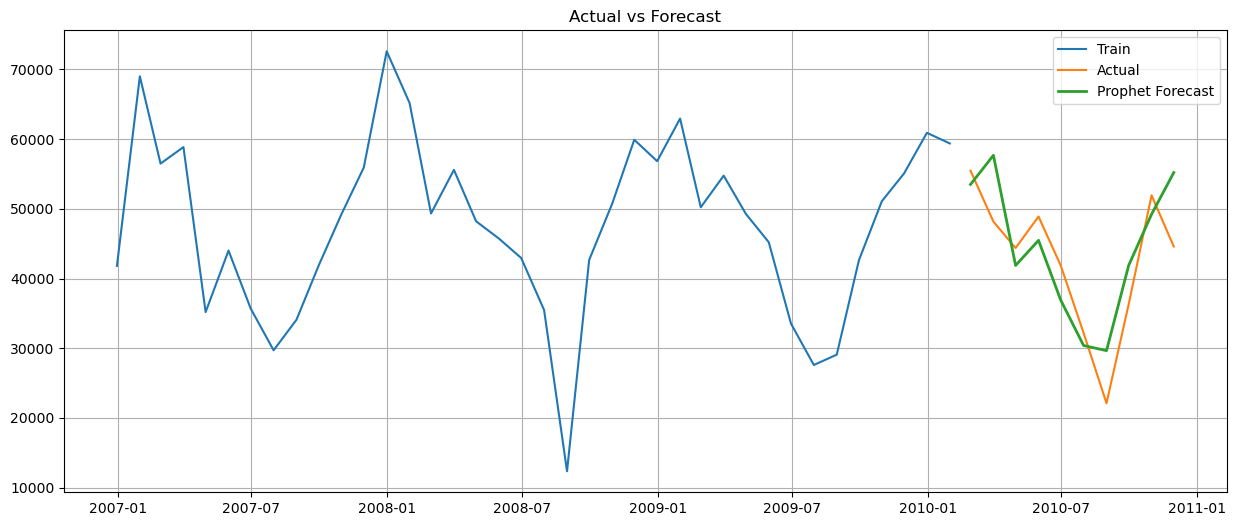

In [34]:
plt.figure(figsize=(15,6))
plt.plot(train.index,train,label="Train")
plt.plot(test.index,test,label="Actual")
plt.plot(test.index,y_pred,label="Prophet Forecast",linewidth=2)
plt.legend()
plt.grid(True)
plt.title("Actual vs Forecast")
plt.show()

In [35]:
MAE = mean_absolute_error(y_true,y_pred)
MSE = mean_squared_error(y_true,y_pred)
RMSE = np.sqrt(MSE)
MAPE = mean_absolute_percentage_error(y_true,y_pred)
R2 = r2_score(y_true,y_pred)

In [36]:
print(f"MAE : {MAE:.2f}")
print(f"MSE : {MSE:.2f}")
print(f"RMSE : {RMSE:.2f}")
print(f"MAPE : {MAPE:.4f}")
print(f"R2 : {R2:.4f}")

MAE : 5060.76
MSE : 34811708.32
RMSE : 5900.14
MAPE : 0.1319
R2 : 0.6128


<div dir="rtl" align="justify">

# تحلیل: مدل‌سازی و پیش‌بینی مصرف برق

---

## هدف این مرحله
<div dir="rtl" align="justify">
پس از آماده‌سازی داده‌ها و بررسی ویژگی‌های سری زمانی، مدل Prophet برای پیش‌بینی مصرف برق در دوره آزمون مورد استفاده قرار گرفت. هدف این مرحله، ارزیابی توانایی مدل در یادگیری روند و فصل‌مندی داده‌ها و بررسی میزان دقت پیش‌بینی در مقایسه با مقادیر واقعی است.
<div dir="rtl" align="justify">
---

## تحلیل نتایج
<div dir="rtl" align="justify">
مقایسه نمودار مقادیر واقعی و پیش‌بینی‌شده نشان می‌دهد مدل Prophet توانسته مسیر کلی تغییرات مصرف برق را به‌خوبی دنبال کند. روند افزایش و کاهش مصرف در بیشتر بازه‌های زمانی با داده‌های واقعی هم‌جهت است و مدل موفق شده بخش عمده‌ای از رفتار زمانی سری را بازسازی کند. این موضوع نشان می‌دهد مصرف برق از الگوی زمانی مشخصی پیروی می‌کند و تغییرات آن کاملاً تصادفی نیست.
<div dir="rtl" align="justify">
با وجود این، در برخی بازه‌های زمانی فاصله قابل مشاهده‌ای بین مقادیر واقعی و پیش‌بینی‌شده وجود دارد. این اختلاف‌ها نشان می‌دهد مدل اگرچه روند کلی و بخش زیادی از فصل‌مندی را به‌درستی یاد گرفته است، اما در بازسازی برخی نوسانات محلی و تغییرات ناگهانی هنوز محدودیت دارد. این موضوع با نتایج مرحله بررسی باقی‌مانده‌ها نیز هم‌خوانی دارد؛ جایی که مشاهده شد بخشی از ساختار زمانی هنوز در داده باقی مانده است.
<div dir="rtl" align="justify">
شاخص‌های ارزیابی نیز همین نتیجه را تأیید می‌کنند. مقدار **MAE برابر با 5060.76** نشان می‌دهد پیش‌بینی‌های مدل به‌طور متوسط حدود پنج هزار واحد با مقادیر واقعی اختلاف داشته‌اند. این مقدار بیانگر آن است که مدل توانسته بخش قابل توجهی از رفتار مصرف را یاد بگیرد، هرچند هنوز خطای قابل اندازه‌گیری در پیش‌بینی‌ها وجود دارد.
<div dir="rtl" align="justify">
همچنین مقدار **RMSE برابر با 5900.14** از مقدار MAE بزرگ‌تر است. این اختلاف نشان می‌دهد در برخی ماه‌ها خطاهای بزرگ‌تری نسبت به میانگین رخ داده است و مدل در همه دوره‌ها با دقت یکسان عمل نکرده است. مقدار **MSE برابر با 34,811,710** نیز همین موضوع را تأیید می‌کند و بیانگر تأثیر بیشتر خطاهای بزرگ در ارزیابی عملکرد مدل است.
<div dir="rtl" align="justify">
از طرف دیگر، مقدار **MAPE برابر با 13.19 درصد** نشان می‌دهد میانگین خطای نسبی مدل حدود سیزده درصد بوده است. برای یک مدل پایه پیش‌بینی سری زمانی، این مقدار قابل قبول ارزیابی می‌شود و بیانگر آن است که پیش‌بینی‌ها در بیشتر ماه‌ها فاصله زیادی با مقادیر واقعی ندارند.
<div dir="rtl" align="justify">
همچنین مقدار **R² برابر با 0.6128** نشان می‌دهد حدود **61 درصد** از تغییرات مصرف برق توسط مدل توضیح داده شده است. بنابراین مدل توانسته بخش عمده‌ای از الگوی مصرف را شناسایی کند، اما هنوز نزدیک به **39 درصد** از تغییرات داده ناشی از عواملی است که در مدل فعلی به‌طور کامل توضیح داده نشده‌اند.
<div dir="rtl" align="justify">
---

## جمع‌بندی
<div dir="rtl" align="justify">
نتایج این مرحله نشان می‌دهد مدل Prophet در شناسایی روند کلی و الگوی فصلی مصرف برق عملکرد قابل قبولی داشته و توانسته پیش‌بینی‌هایی نزدیک به مقادیر واقعی ارائه دهد. با این حال، اختلاف موجود در برخی ماه‌ها، مقدار خطاهای ارزیابی و مقدار R² نشان می‌دهد هنوز بخشی از رفتار سری زمانی توسط مدل پوشش داده نشده است. به همین دلیل، در ادامه عملکرد Prophet با مدل ARIMA مقایسه می‌شود تا مشخص شود کدام مدل می‌تواند الگوهای باقی‌مانده را بهتر یاد گرفته و پیش‌بینی دقیق‌تری ارائه دهد.
<div dir="rtl" align="justify">
</div>

<div dir="rtl" align="justify">

In [37]:
model_no_seasonality = Prophet(yearly_seasonality=False)
model_no_seasonality.fit(train_prophet)

04:07:41 - cmdstanpy - INFO - Chain [1] start processing
04:07:41 - cmdstanpy - INFO - Chain [1] done processing


In [38]:
forecast_no_seasonality = (model_no_seasonality.predict(future))

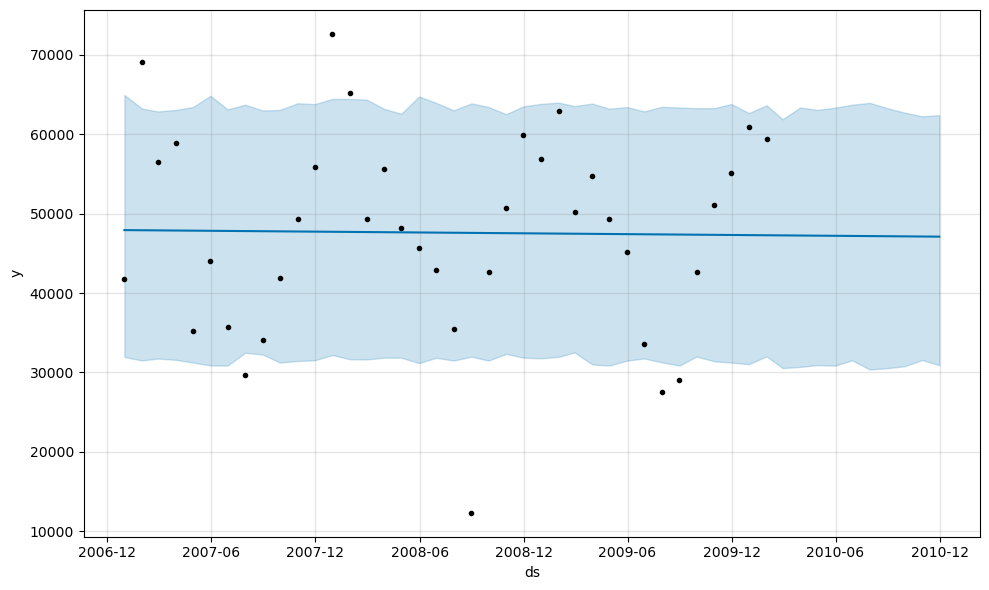

In [39]:
model_no_seasonality.plot(forecast_no_seasonality)
plt.grid(True)
plt.show()

In [40]:
y_pred2 = forecast_no_seasonality["yhat"].iloc[-len(test):].values

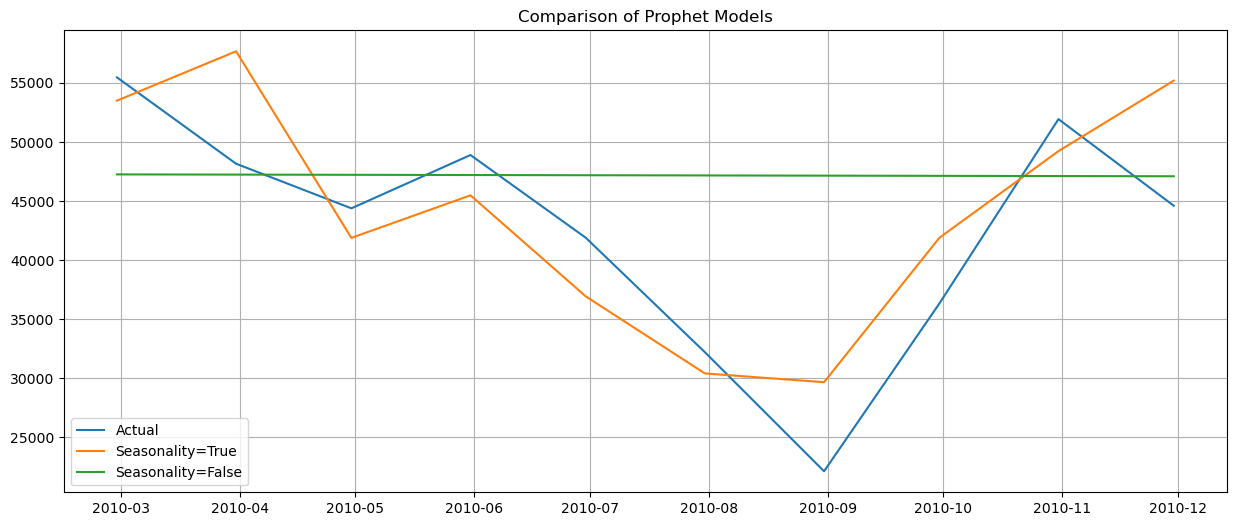

In [41]:
plt.figure(figsize=(15,6))
plt.plot(test.index,test,label="Actual")
plt.plot(test.index,y_pred,label="Seasonality=True")
plt.plot(test.index,y_pred2,label="Seasonality=False")
plt.legend()
plt.grid(True)
plt.title("Comparison of Prophet Models")
plt.show()

<div dir="rtl" align="justify">

# تحلیل: مقایسه مدل با و بدون فصل‌مندی
<div dir="rtl" align="justify">
در این بخش، عملکرد مدل Prophet در دو حالت **با در نظر گرفتن فصل‌مندی سالانه** و **بدون فصل‌مندی** با یکدیگر مقایسه شد. بررسی نمودارها نشان می‌دهد زمانی که مؤلفه فصل‌مندی در مدل فعال است، مسیر پیش‌بینی در بیشتر بازه‌های زمانی به مقادیر واقعی نزدیک‌تر بوده و تغییرات مصرف برق را بهتر دنبال می‌کند.
<div dir="rtl" align="justify">
در مقابل، با حذف فصل‌مندی، پیش‌بینی‌ها از روند واقعی فاصله بیشتری می‌گیرند و مدل در دنبال کردن افت‌وخیزهای دوره‌ای عملکرد ضعیف‌تری دارد. این اختلاف نشان می‌دهد بخش قابل توجهی از تغییرات مصرف برق ناشی از الگوهای تکرارشونده سالانه است و حذف این مؤلفه باعث از دست رفتن بخشی از اطلاعات مهم سری زمانی می‌شود.
<div dir="rtl" align="justify">
نتایج این مقایسه تأیید می‌کند که مصرف برق تنها از یک روند بلندمدت تشکیل نشده و فصل‌مندی یکی از مؤلفه‌های اصلی رفتار این داده است. بنابراین، استفاده از مدل دارای فصل‌مندی باعث می‌شود پیش‌بینی‌ها به واقعیت نزدیک‌تر باشند و مدل بتواند رفتار آینده مصرف برق را با دقت بیشتری برآورد کند.
<div dir="rtl" align="justify">
</div>

In [42]:
arima = ARIMA(train,order=(1,1,1))
arima_fit = arima.fit()

In [43]:
forecast_arima = arima_fit.forecast(steps=len(test))

In [44]:
MAE_ARIMA = mean_absolute_error(test,forecast_arima)
MSE_ARIMA = mean_squared_error(test,forecast_arima)
RMSE_ARIMA = np.sqrt(MSE_ARIMA)
MAPE_ARIMA = mean_absolute_percentage_error(test,forecast_arima)
R2_ARIMA = r2_score(test,forecast_arima)

In [45]:
print(f"MAE : {MAE_ARIMA:.2f}")
print(f"MSE : {MSE_ARIMA:.2f}")
print(f"RMSE : {RMSE_ARIMA:.2f}")
print(f"MAPE : {MAPE_ARIMA:.4f}")
print(f"R2 : {R2_ARIMA:.4f}")

MAE : 16687.73
MSE : 368347122.21
RMSE : 19192.37
MAPE : 0.4890
R2 : -3.0973


<div dir="rtl" align="justify">

# تحلیل: ارزیابی عملکرد مدل ARIMA
<div dir="rtl" align="justify">
---

## هدف این مرحله
<div dir="rtl" align="justify">
در این بخش، عملکرد مدل ARIMA برای پیش‌بینی مصرف برق بررسی شد تا مشخص شود این مدل تا چه اندازه می‌تواند روند و الگوهای موجود در داده را یاد گرفته و مقادیر آینده را پیش‌بینی کند.
<div dir="rtl" align="justify">
---

## تحلیل نتایج
<div dir="rtl" align="justify">
مقایسه مقادیر واقعی و پیش‌بینی‌شده نشان می‌دهد مدل ARIMA نتوانسته مسیر واقعی تغییرات مصرف برق را به‌خوبی دنبال کند. در بخش قابل توجهی از دوره آزمون، اختلاف محسوسی بین مقادیر پیش‌بینی‌شده و داده‌های واقعی مشاهده می‌شود و مدل در بازسازی روند کلی و نوسانات مصرف عملکرد مطلوبی نداشته است.
<div dir="rtl" align="justify">
شاخص‌های ارزیابی نیز این موضوع را به‌وضوح تأیید می‌کنند. مقدار **MAE برابر با 16687.73** نشان می‌دهد پیش‌بینی‌های مدل به‌طور متوسط بیش از شانزده هزار واحد با مقادیر واقعی اختلاف داشته‌اند که نسبت به مدل Prophet فاصله بسیار بیشتری دارد.
<div dir="rtl" align="justify">
همچنین مقدار **RMSE برابر با 19192.37** از مقدار MAE نیز بزرگ‌تر است. این اختلاف بیانگر آن است که در برخی بازه‌های زمانی، خطاهای پیش‌بینی بسیار بزرگ بوده‌اند و مدل نتوانسته تغییرات واقعی مصرف را به‌درستی بازسازی کند. مقدار **MSE برابر با 368,347,100** نیز همین موضوع را تأیید می‌کند و نشان می‌دهد اثر خطاهای بزرگ در عملکرد مدل قابل توجه بوده است.
<div dir="rtl" align="justify">
مقدار **MAPE برابر با 48.90 درصد** نیز نشان می‌دهد پیش‌بینی‌های مدل به‌طور متوسط نزدیک به نیمی از مقدار واقعی اختلاف داشته‌اند. چنین میزان خطایی برای پیش‌بینی مصرف برق قابل قبول نیست و بیانگر دقت پایین مدل در این مجموعه داده است.
<div dir="rtl" align="justify">
مهم‌ترین شاخص این بخش، مقدار **R² برابر با 3.0973-** است. منفی بودن این شاخص نشان می‌دهد مدل ARIMA نتوانسته تغییرات مصرف برق را توضیح دهد و عملکرد آن حتی از یک مدل پایه که تنها میانگین داده‌ها را پیش‌بینی می‌کند نیز ضعیف‌تر بوده است. این نتیجه نشان می‌دهد ساختار انتخاب‌شده برای مدل نتوانسته الگوهای موجود در سری زمانی را به‌درستی یاد بگیرد.
<div dir="rtl" align="justify">
---

## جمع‌بندی
<div dir="rtl" align="justify">
نتایج این مرحله نشان می‌دهد مدل ARIMA در پیش‌بینی مصرف برق عملکرد رضایت‌بخشی نداشته است. مقادیر بالای MAE، RMSE و MAPE در کنار مقدار منفی R² بیان می‌کنند که این مدل نتوانسته روند و نوسانات واقعی داده را به‌خوبی بازسازی کند. در مقایسه با Prophet، دقت ARIMA به‌طور محسوسی پایین‌تر است؛ بنابراین برای این مجموعه داده، Prophet گزینه مناسب‌تری برای پیش‌بینی مصرف برق محسوب می‌شود.
<div dir="rtl" align="justify">
</div>

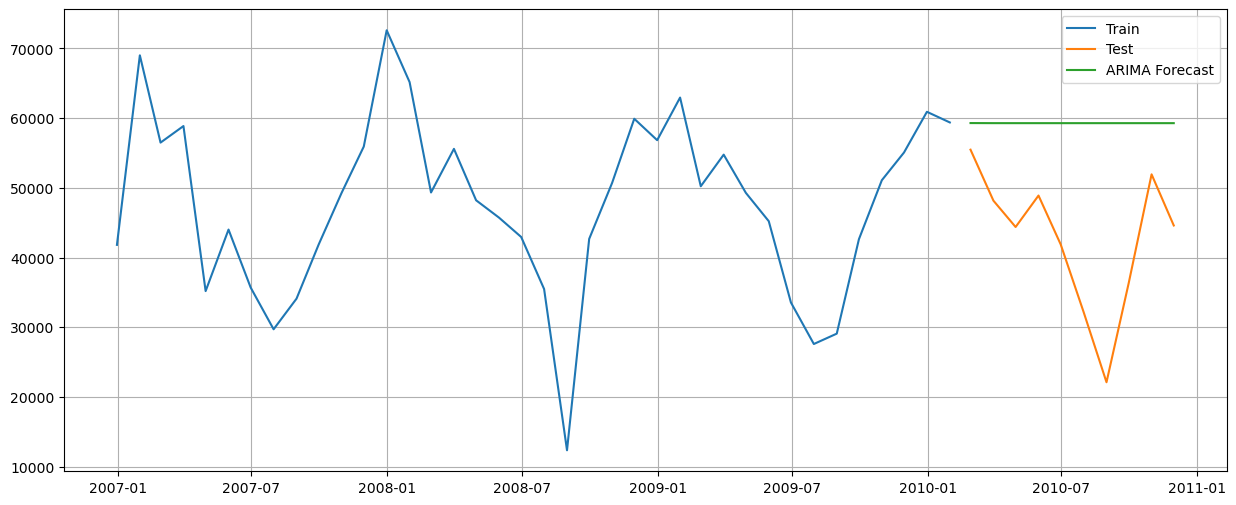

In [46]:
plt.figure(figsize=(15,6))
plt.plot(train.index,train,label="Train")
plt.plot(test.index,test,label="Test")
plt.plot(test.index,forecast_arima,label="ARIMA Forecast")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
comparison = pd.DataFrame({
"Model":["Prophet","ARIMA"],
"MAE":[MAE,MAE_ARIMA],
"MSE":[MSE,MSE_ARIMA],
"RMSE":[RMSE,RMSE_ARIMA],
"MAPE":[MAPE,MAPE_ARIMA],
"R2":[R2,R2_ARIMA]})
comparison

,Model,MAE,MSE,RMSE,MAPE,R2
0,Prophet,5060.763494,3.481171e+07,5900.144771,0.131873,0.612777
1,ARIMA,16687.725827,3.683471e+08,19192.371459,0.488986,-3.097252


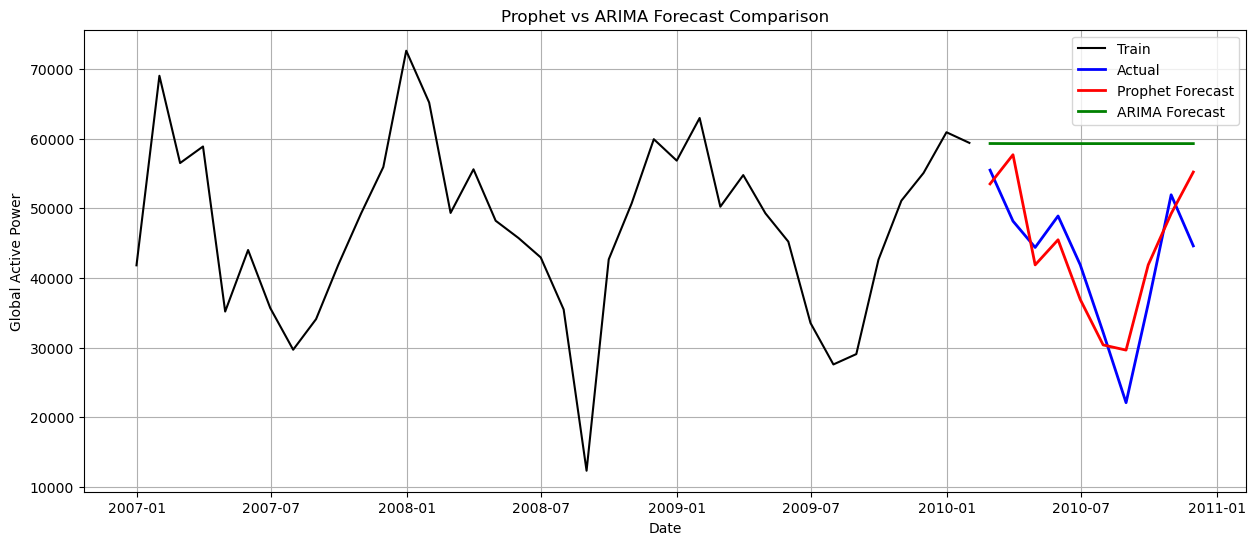

In [48]:
plt.figure(figsize=(15,6))
plt.plot(train.index,train,label="Train",color="black")
plt.plot(test.index,test,label="Actual",color="blue",linewidth=2)
plt.plot(test.index,y_pred,label="Prophet Forecast",color="red",linewidth=2)
plt.plot(test.index,forecast_arima,label="ARIMA Forecast",color="green",linewidth=2)
plt.title("Prophet vs ARIMA Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.grid(True)
plt.legend()
plt.show()

<div dir="rtl" align="justify">

# تحلیل: مقایسه Prophet و ARIMA
<div dir="rtl" align="justify">
---

## هدف این مرحله
<div dir="rtl" align="justify">
در این بخش، خروجی دو مدل Prophet و ARIMA روی یک نمودار مقایسه شد تا مشخص شود کدام مدل توانسته رفتار واقعی مصرف برق را با دقت بیشتری بازسازی کند.

---
<div dir="rtl" align="justify">
## تحلیل نتایج
<div dir="rtl" align="justify">
بررسی نمودار مقایسه‌ای نشان می‌دهد خط پیش‌بینی **Prophet** در بیشتر بازه‌های زمانی فاصله کمتری با مقادیر واقعی دارد و تغییرات اصلی مصرف برق را بهتر دنبال می‌کند. این مدل در زمان افزایش و کاهش مصرف، مسیر داده را با دقت بیشتری بازسازی کرده و هماهنگی بیشتری با روند واقعی سری زمانی دارد.
<div dir="rtl" align="justify">
در مقابل، پیش‌بینی‌های **ARIMA** در چندین بازه زمانی از مسیر واقعی فاصله گرفته‌اند و در دنبال کردن افت‌وخیزهای مصرف عملکرد ضعیف‌تری نشان می‌دهند. نمودار بیانگر آن است که این مدل نتوانسته همه تغییرات دوره‌ای موجود در داده را به‌خوبی یاد بگیرد و در برخی نقاط، اختلاف قابل توجهی بین مقادیر واقعی و پیش‌بینی‌شده مشاهده می‌شود.
<div dir="rtl" align="justify">
این نتایج با شاخص‌های ارزیابی نیز کاملاً هم‌خوانی دارند. مقادیر پایین‌تر **MAE، RMSE و MAPE** و همچنین مقدار بالاتر **R²** در مدل Prophet نشان می‌دهد این مدل نسبت به ARIMA توانسته بخش بیشتری از تغییرات مصرف برق را توضیح دهد و پیش‌بینی‌های دقیق‌تری ارائه کند.
<div dir="rtl" align="justify">
---

## جمع‌بندی
<div dir="rtl" align="justify">
مقایسه دو مدل نشان می‌دهد **Prophet** در این پروژه عملکرد بهتری نسبت به **ARIMA** داشته است. این مدل هم از نظر نمودار پیش‌بینی و هم از نظر شاخص‌های ارزیابی، به مقادیر واقعی نزدیک‌تر بوده و الگوی مصرف برق را با دقت بیشتری بازسازی کرده است. بنابراین، برای این مجموعه داده، Prophet به‌عنوان مدل نهایی برای پیش‌بینی مصرف برق انتخاب می‌شود و می‌تواند مبنای مناسب‌تری برای تحلیل و تصمیم‌گیری قرار گیرد.
<div dir="rtl" align="justify">
</div>

In [49]:
sarima = SARIMAX(train,order=(1, 1, 1),seasonal_order=(1, 1, 1, 12),enforce_stationarity=False,enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)

In [50]:
forecast_sarima = sarima_fit.forecast(steps=len(test))

In [51]:
MAE_SARIMA = mean_absolute_error(test, forecast_sarima)
MSE_SARIMA = mean_squared_error(test, forecast_sarima)
RMSE_SARIMA = np.sqrt(MSE_SARIMA)
MAPE_SARIMA = mean_absolute_percentage_error(test, forecast_sarima)
R2_SARIMA = r2_score(test, forecast_sarima)
print(f"MAE : {MAE_SARIMA:.2f}")
print(f"MSE : {MSE_SARIMA:.2f}")
print(f"RMSE : {RMSE_SARIMA:.2f}")
print(f"MAPE : {MAPE_SARIMA:.4f}")
print(f"R2 : {R2_SARIMA:.4f}")

MAE : 5125.66
MSE : 33172480.02
RMSE : 5759.56
MAPE : 0.1236
R2 : 0.6310


In [52]:
comparison = pd.DataFrame({
"Model": ["Prophet", "ARIMA", "SARIMA"],
"MAE": [MAE, MAE_ARIMA, MAE_SARIMA],
"MSE": [MSE, MSE_ARIMA, MSE_SARIMA],
"RMSE": [RMSE, RMSE_ARIMA, RMSE_SARIMA],
"MAPE": [MAPE, MAPE_ARIMA, MAPE_SARIMA],
"R2": [R2, R2_ARIMA, R2_SARIMA]
})
comparison

,Model,MAE,MSE,RMSE,MAPE,R2
0,Prophet,5060.763494,3.481171e+07,5900.144771,0.131873,0.612777
1,ARIMA,16687.725827,3.683471e+08,19192.371459,0.488986,-3.097252
2,SARIMA,5125.655816,3.317248e+07,5759.555540,0.123622,0.631011


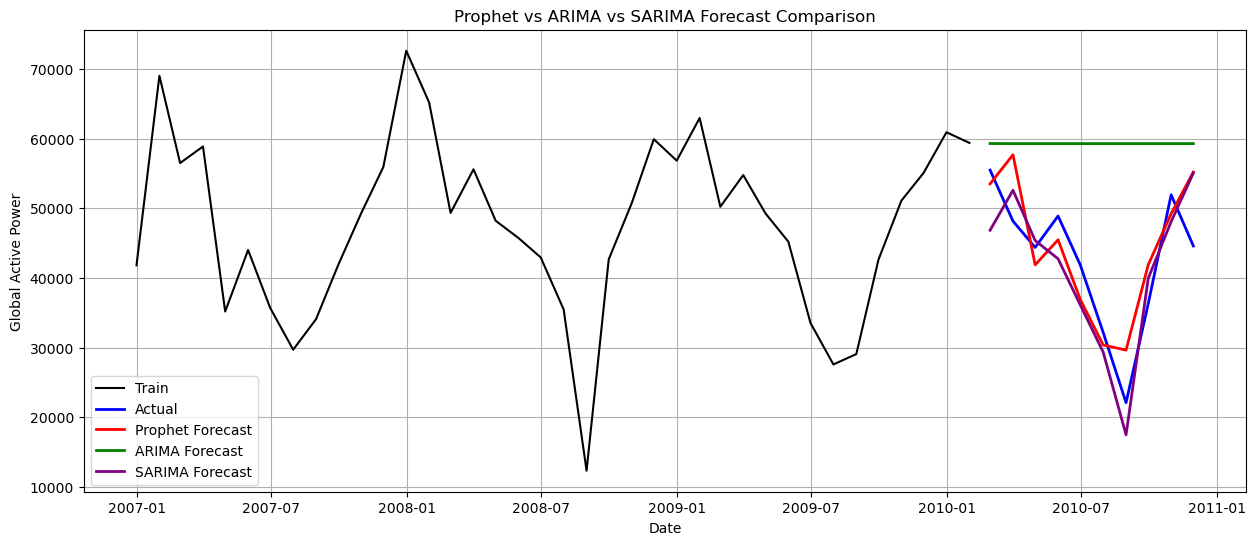

In [53]:
plt.figure(figsize=(15,6))
plt.plot(train.index,train,label="Train",color="black")
plt.plot(test.index,test,label="Actual",color="blue",linewidth=2)
plt.plot(test.index,y_pred,label="Prophet Forecast",color="red",linewidth=2)
plt.plot(test.index,forecast_arima,label="ARIMA Forecast",color="green",linewidth=2)
plt.plot(test.index,forecast_sarima,label="SARIMA Forecast",color="purple",linewidth=2)
plt.title("Prophet vs ARIMA vs SARIMA Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.grid(True)
plt.legend()
plt.show()

<div dir="rtl" align="justify">

# تحلیل: مقایسه نهایی مدل‌های Prophet، SARIMA و ARIMA
<div dir="rtl" align="justify">
---

## هدف این مرحله
<div dir="rtl" align="justify">
در این بخش، عملکرد سه مدل **Prophet**، **SARIMA** و **ARIMA** با استفاده از نمودار مقایسه‌ای و شاخص‌های ارزیابی بررسی شد تا مناسب‌ترین مدل برای پیش‌بینی مصرف برق انتخاب شود.
<div dir="rtl" align="justify">
---

## تحلیل نتایج
<div dir="rtl" align="justify">
بررسی نمودار مقایسه‌ای نشان می‌دهد مدل **Prophet** در بیشتر بازه‌های زمانی بیشترین تطابق را با مقادیر واقعی دارد و روند تغییرات مصرف برق را با دقت بیشتری دنبال می‌کند. فاصله خط پیش‌بینی این مدل از داده‌های واقعی کمتر بوده و نوسان‌های اصلی مصرف را بهتر بازسازی کرده است.
<div dir="rtl" align="justify">
مدل **SARIMA** نیز نسبت به **ARIMA** عملکرد بهتری داشته است. با در نظر گرفتن مؤلفه فصلی، این مدل توانسته بخشی از تغییرات دوره‌ای مصرف را یاد بگیرد و پیش‌بینی‌های دقیق‌تری نسبت به ARIMA ارائه دهد. با این حال، در برخی بازه‌ها همچنان اختلاف قابل توجهی بین مقادیر واقعی و پیش‌بینی‌شده مشاهده می‌شود و دقت آن به سطح Prophet نمی‌رسد.
<div dir="rtl" align="justify">
در مقابل، **ARIMA** بیشترین فاصله را با داده‌های واقعی نشان می‌دهد و در دنبال کردن تغییرات مصرف برق عملکرد ضعیف‌تری دارد. این موضوع با شاخص‌های ارزیابی نیز هم‌خوانی دارد و بیان می‌کند که این مدل نتوانسته ساختار زمانی داده را به‌طور کامل یاد بگیرد.
<div dir="rtl" align="justify">
نتایج جدول مقایسه نیز همین ترتیب را تأیید می‌کند؛ به‌گونه‌ای که Prophet کمترین میزان خطا و بهترین عملکرد را داشته، SARIMA در رتبه دوم قرار گرفته و ARIMA ضعیف‌ترین نتیجه را ثبت کرده است. این مقایسه نشان می‌دهد که وجود فصل‌مندی سالانه یکی از ویژگی‌های اصلی این سری زمانی است و مدل‌هایی که این مؤلفه را بهتر مدیریت می‌کنند، پیش‌بینی دقیق‌تری ارائه می‌دهند.
<div dir="rtl" align="justify">
---

## جمع‌بندی
<div dir="rtl" align="justify">
مقایسه نهایی سه مدل نشان می‌دهد **Prophet** بهترین عملکرد را در پیش‌بینی مصرف برق داشته و توانسته هم روند بلندمدت و هم الگوهای فصلی را با دقت بیشتری بازسازی کند. **SARIMA** نیز نسبت به **ARIMA** بهبود قابل توجهی داشته است، اما همچنان از نظر دقت و نزدیکی به داده‌های واقعی پایین‌تر از Prophet قرار می‌گیرد. بنابراین، با توجه به نتایج نمودارها و شاخص‌های ارزیابی، **Prophet به‌عنوان مناسب‌ترین مدل برای این مجموعه داده انتخاب می‌شود** و می‌تواند مبنای قابل‌اعتمادتری برای پیش‌بینی مصرف برق و تصمیم‌گیری‌های آتی باشد.
<div dir="rtl" align="justify">
</div>

In [55]:
full_prophet = monthly_power.reset_index()
full_prophet.columns = ["ds","y"]
final_model = Prophet(yearly_seasonality=True)
final_model.fit(full_prophet)
future_24 = final_model.make_future_dataframe(periods=24,freq="ME")
forecast_24 = final_model.predict(future_24)

09:29:42 - cmdstanpy - INFO - Chain [1] start processing
09:29:42 - cmdstanpy - INFO - Chain [1] done processing


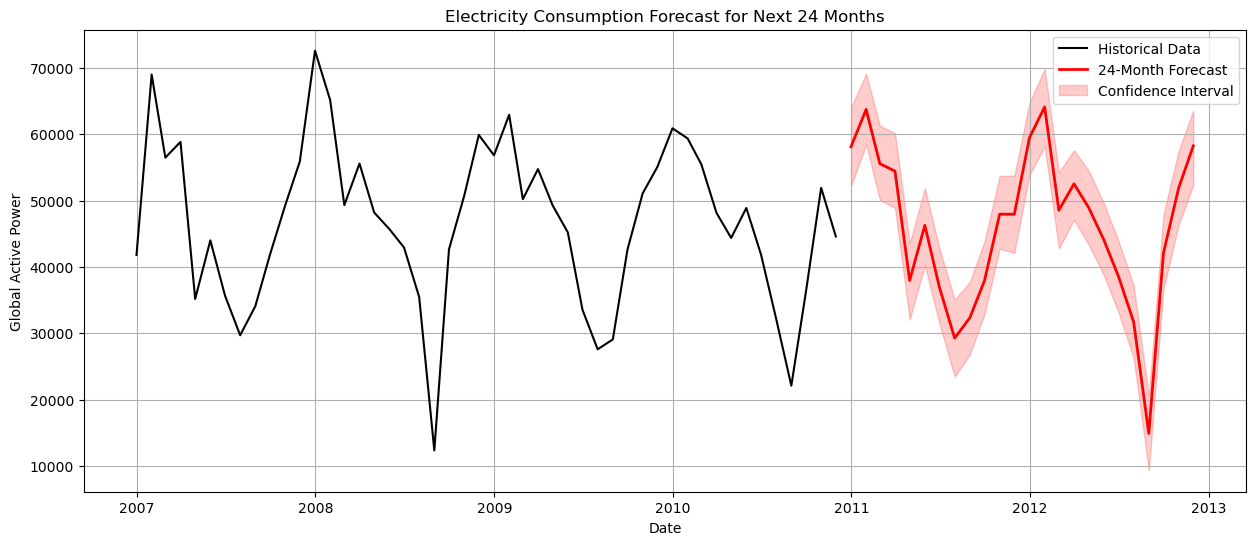

In [56]:
plt.figure(figsize=(15,6))
plt.plot(monthly_power.index,monthly_power,label="Historical Data",color="black")
plt.plot(forecast_24["ds"].iloc[-24:],forecast_24["yhat"].iloc[-24:],label="24-Month Forecast",color="red",linewidth=2)
plt.fill_between(forecast_24["ds"].iloc[-24:],forecast_24["yhat_lower"].iloc[-24:],forecast_24["yhat_upper"].iloc[-24:],color="red",alpha=0.2,label="Confidence Interval")
plt.title("Electricity Consumption Forecast for Next 24 Months")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.grid(True)
plt.legend()
plt.show()

<div dir="rtl" align="justify">
پیش‌بینی مصرف برق 24 ماه آینده با Prophet
<div dir="rtl" align="justify">
هدف این مرحله
<div dir="rtl" align="justify">
هدف از این بخش، پیش‌بینی مصرف برق برای ۲۴ ماه آینده با استفاده از مدل Prophet و ارزیابی روند، الگوی فصلی و میزان اطمینان پیش‌بینی‌ها است.
<div dir="rtl" align="justify">
تحلیل نتایج
<div dir="rtl" align="justify">
مدل Prophet با استفاده از داده‌های تاریخی، روند مصرف برق را برای ۲۴ ماه آینده پیش‌بینی کرده است. نمودار نشان می‌دهد که پیش‌بینی‌ها دارای نوسان منظم هستند و الگوی فصلی مشاهده‌شده در داده‌های گذشته در دوره آینده نیز حفظ شده است.
<div dir="rtl" align="justify">
بیشتر مقادیر پیش‌بینی در بازه‌ای مشابه داده‌های تاریخی قرار دارند، اما در اواخر دوره یک افت قابل توجه در مصرف مشاهده می‌شود که همزمان با افزایش عرض بازه اطمینان است. این موضوع نشان می‌دهد عدم قطعیت مدل در آن بازه بیشتر از سایر ماه‌هاست.
<div dir="rtl" align="justify">
نتایج ارزیابی نیز عملکرد قابل قبول مدل را تأیید می‌کنند. مقدار MAE برابر با 5060.76 و RMSE برابر با 5900.14 بیانگر خطای متوسط نسبتاً محدود مدل هستند. همچنین MAPE برابر با 13.19٪ نشان می‌دهد اختلاف پیش‌بینی با مقادیر واقعی به طور میانگین حدود ۱۳ درصد است. مقدار R² برابر با 0.6128 نیز نشان می‌دهد مدل حدود ۶۱ درصد از تغییرات مصرف برق را توضیح داده است.
<div dir="rtl" align="justify">
جمع‌بندی
<div dir="rtl" align="justify">
مدل Prophet توانسته روند و الگوی فصلی مصرف برق را با دقت قابل قبولی شناسایی و پیش‌بینی کند. 
</div>

In [59]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_sarima = SARIMAX(
    monthly_power,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima.fit(disp=False)

In [60]:
forecast_24 = final_sarima_fit.get_forecast(steps=24)

forecast_mean = forecast_24.predicted_mean

conf_int = forecast_24.conf_int()

future_dates = pd.date_range(
    start=monthly_power.index[-1] + pd.offsets.MonthEnd(1),
    periods=24,
    freq="ME"
)

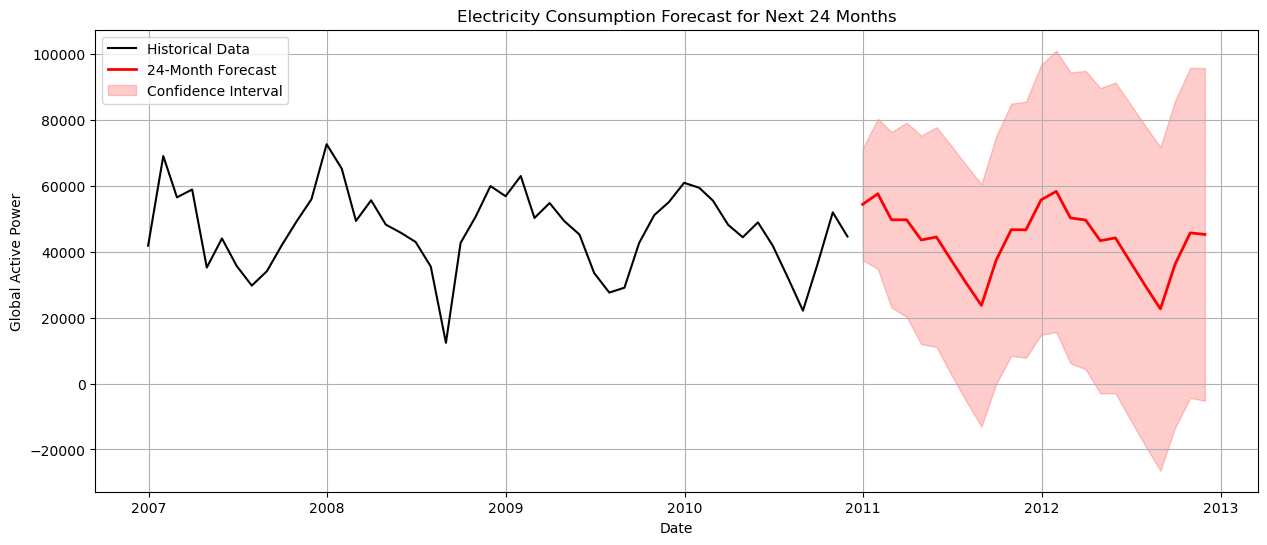

In [61]:
plt.figure(figsize=(15,6))
plt.plot(monthly_power.index,monthly_power,label="Historical Data",color="black")
plt.plot(future_dates,forecast_mean,label="24-Month Forecast",color="red",linewidth=2)
plt.fill_between(future_dates,conf_int.iloc[:,0],conf_int.iloc[:,1],color="red",alpha=0.2,label="Confidence Interval")
plt.title("Electricity Consumption Forecast for Next 24 Months")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.grid(True)
plt.legend()
plt.show()

<div dir="rtl" align="justify">
پیش‌بینی مصرف برق 24 ماه آینده با SARIMA
هدف این مرحله
<div dir="rtl" align="justify">
هدف از این بخش، پیش‌بینی مصرف برق برای ۲۴ ماه آینده با استفاده از مدل SARIMA و بررسی روند پیش‌بینی و میزان عدم قطعیت مدل در افق زمانی آینده است.
<div dir="rtl" align="justify">
تحلیل نتایج
<div dir="rtl" align="justify">
مدل SARIMA روند مصرف برق را با حفظ الگوی فصلی داده‌های تاریخی پیش‌بینی کرده است. خط قرمز نشان می‌دهد که مصرف برق در ماه‌های آینده همچنان نوسان خواهد داشت و مقادیر پیش‌بینی عمدتاً در بازه حدود ۲۳ تا ۵۸ هزار واحد قرار گرفته‌اند. این موضوع بیانگر آن است که مدل انتظار تغییر ناگهانی در سطح کلی مصرف را ندارد و رفتار گذشته را به آینده تعمیم داده است.
<div dir="rtl" align="justify">
نکته قابل توجه، افزایش تدریجی عرض بازه اطمینان در طول افق پیش‌بینی است. هرچه فاصله زمانی از آخرین داده واقعی بیشتر می‌شود، فاصله بین کران بالا و پایین افزایش می‌یابد؛ به‌طوری‌که در ماه‌های پایانی بازه اطمینان بسیار گسترده شده و حتی کران پایین به مقادیر منفی نیز رسیده است. با توجه به اینکه مصرف برق نمی‌تواند مقدار منفی داشته باشد، این موضوع نشان می‌دهد عدم قطعیت مدل در پیش‌بینی‌های بلندمدت افزایش یافته و قابلیت اتکای پیش‌بینی در انتهای دوره نسبت به ماه‌های ابتدایی کمتر است.
<div dir="rtl" align="justify">
جمع‌بندی
<div dir="rtl" align="justify">
مدل SARIMA توانسته الگوی فصلی مصرف برق را در افق ۲۴ ماهه حفظ کند، اما افزایش قابل توجه بازه اطمینان نشان می‌دهد با دور شدن از داده‌های واقعی، عدم قطعیت پیش‌بینی بیشتر می‌شود.  

<div dir="rtl" align="justify">

### جواب سوالات پروژه

### آیا میانگین متحرک توانسته است روند واقعی داده را بهتر نمایان کند؟ چرا؟
<div dir="rtl" align="justify">
بله؛ میانگین متحرک نوسانات کوتاه‌مدت را کاهش داد و روند کلی تغییرات مصرف برق را واضح‌تر نشان داد.
<div dir="rtl" align="justify">
---

### اگر از پنجره ۶ ماهه استفاده شود، چه تغییری ایجاد می‌شود؟ (بدون اجرای کد استدلال کنید)
<div dir="rtl" align="justify">
میانگین متحرک حساس‌تر می‌شود، نوسانات بیشتری حفظ می‌شوند و روند کلی نسبت به پنجره ۱۲ ماهه هموارتر نخواهد بود.
<div dir="rtl" align="justify">
---

### آیا نشانه‌ای از تغییر روند یا تغییر رفتار مصرف در طول زمان مشاهده می‌شود؟ (مستند به نمودار)
<div dir="rtl" align="justify">
بله؛ نمودار روند نشان می‌دهد مصرف برق در برخی دوره‌ها تغییرات محسوسی داشته، اما رفتار کلی سری زمانی در طول سال‌ها نسبتاً پایدار باقی مانده است.
<div dir="rtl" align="justify">
---

### استفاده از مدل Additive برای این داده مناسب‌تر است یا Multiplicative؟
<div dir="rtl" align="justify">
مدل Additive مناسب‌تر است؛ زیرا دامنه نوسانات فصلی در طول زمان تقریباً ثابت مانده و متناسب با روند افزایش یا کاهش پیدا نکرده است.
<div dir="rtl" align="justify">
---

### اگر مقدار period به اشتباه برابر ۶ در نظر گرفته شود، انتظار چه اثری بر مؤلفه Seasonal دارید؟
<div dir="rtl" align="justify">
مدل یک الگوی فصلی شش‌ماهه مصنوعی ایجاد می‌کند و بخشی از فصل‌مندی واقعی سالانه به مؤلفه‌های Trend و Residual منتقل می‌شود.
<div dir="rtl" align="justify">
---

### آیا Residualها دارای الگوی مشخص هستند؟ وجود الگو در باقیمانده‌ها به چه معناست؟
<div dir="rtl" align="justify">
بله؛ وجود خودهمبستگی در وقفه ۱۲ نشان می‌دهد بخشی از الگوی فصلی هنوز در باقی‌مانده‌ها وجود دارد و مدل تمام ساختار داده را استخراج نکرده است.
<div dir="rtl" align="justify">
---

### آیا روند پیش‌بینی‌شده با روند تاریخی سازگار است؟ توضیح دهید.
<div dir="rtl" align="justify">
بله؛ مدل Prophet روند کلی و تغییرات اصلی مصرف برق را به‌خوبی دنبال کرده، هرچند در برخی ماه‌ها اختلاف‌هایی با مقادیر واقعی مشاهده می‌شود.
<div dir="rtl" align="justify">
---

### اگر yearly_seasonality=False تنظیم شود، انتظار دارید پیش‌بینی چگونه تغییر کند؟
<div dir="rtl" align="justify">
دقت پیش‌بینی کاهش می‌یابد و مدل بخشی از نوسانات سالانه مصرف برق را از دست می‌دهد؛ بنابراین فاصله پیش‌بینی از داده‌های واقعی بیشتر می‌شود.
<div dir="rtl" align="justify">
---

### Prophet روند آینده را بر اساس چه مؤلفه‌هایی تخمین می‌زند؟
<div dir="rtl" align="justify">
Prophet روند آینده را بر اساس روند (Trend)، فصل‌مندی (Seasonality) و الگوهای زمانی موجود در داده‌های تاریخی تخمین می‌زند.
<div dir="rtl" align="justify">
---

### چه معیارهای آماری دیگری برای ارزیابی عملکرد مدل مورد نیاز است؟
<div dir="rtl" align="justify">
علاوه بر MAE، RMSE، MAPE و R²، معیارهایی مانند AIC، BIC، SMAPE و آزمون Ljung–Box نیز می‌توانند برای ارزیابی بهتر مدل استفاده شوند.
<div dir="rtl" align="justify">
---

### آیا داده‌های موجود برای چنین تصمیم کلانی کافی هستند؟ چرا؟
<div dir="rtl" align="justify">
خیر؛ اگرچه داده‌های تاریخی برای مدل‌سازی مناسب هستند، اما برای تصمیم‌های کلان بهتر است متغیرهای مؤثر دیگری نیز در مدل لحاظ شوند.
<div dir="rtl" align="justify">
---

### چه عواملی ممکن است باعث شوند پیش‌بینی Prophet در آینده با خطا مواجه شود؟
<div dir="rtl" align="justify">
تغییرات ناگهانی در الگوی مصرف، شرایط آب‌وهوایی، سیاست‌های انرژی، افزایش جمعیت و رخدادهای غیرمنتظره می‌توانند باعث کاهش دقت پیش‌بینی شوند.
<div dir="rtl" align="justify">
---
</div>

<div dir="rtl" align="justify">

### اگر امکان اضافه کردن ۳ متغیر جدید به مدل را داشته باشید، چه متغیرهایی انتخاب می‌کنید؟ دلیل انتخاب هر کدام چیست؟

<div dir="rtl" align="justify"> 
**1. دمای هوا (Temperature)** 
<div dir="rtl" align="justify"> 
دمای هوا مهم‌ترین عامل مؤثر بر مصرف برق خانگی است. در روزهای بسیار گرم یا بسیار سرد، استفاده از وسایل سرمایشی و گرمایشی افزایش پیدا می‌کند و این موضوع مستقیماً مصرف برق را تغییر می‌دهد. اضافه شدن این متغیر می‌تواند دقت پیش‌بینی را به‌طور قابل توجهی افزایش دهد.
<div dir="rtl" align="justify">
**2. تعطیلات رسمی و مناسبت‌ها (Holiday & Calendar Events)**  
<div dir="rtl" align="justify"> 
رفتار مصرف برق در تعطیلات با روزهای عادی تفاوت دارد؛ زیرا الگوی حضور افراد در خانه و ساعات استفاده از وسایل برقی تغییر می‌کند. اضافه کردن تقویم تعطیلات به مدل کمک می‌کند تغییرات غیرعادی مصرف را بهتر شناسایی کند.
<div dir="rtl" align="justify">
**3. شاخص شرایط آب‌وهوایی (Weather Severity Index)** 
<div dir="rtl" align="justify"> 
به‌جای استفاده از تنها یک متغیر مانند دما، می‌توان شاخصی ترکیبی شامل دما، رطوبت، سرعت باد و میزان بارندگی تعریف کرد. این شاخص شدت شرایط جوی را به‌صورت یک متغیر خلاصه می‌کند و می‌تواند تغییرات مصرف ناشی از شرایط محیطی را بهتر از یک متغیر منفرد توضیح دهد.
</div>